In [9]:
# Reconnect to your Drive project folder from WP1 — no need to redownload anything.
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/esm2-variant-benchmark'
os.makedirs(f'{PROJECT_DIR}/data/processed/homologs', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed/alignments', exist_ok=True)

import pandas as pd
print('Ready.')

Mounted at /content/drive
Ready.


In [10]:
# MMseqs2: fast sequence search tool, used here to find homologous proteins.
# MAFFT: standard multiple sequence alignment tool.
# Both installed as standalone binaries — no conda needed, keeps this light.
!wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
!tar xzf mmseqs-linux-avx2.tar.gz
!apt-get install -qq mafft
os.environ['PATH'] += ':/content/mmseqs/bin'
!mmseqs version
!mafft --version

Extracting templates from packages: 100%
Selecting previously unselected package fonts-lato.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../00-fonts-lato_2.0-2.1_all.deb ...
Unpacking fonts-lato (2.0-2.1) ...
Selecting previously unselected package netbase.
Preparing to unpack .../01-netbase_6.3_all.deb ...
Unpacking netbase (6.3) ...
Selecting previously unselected package libclone-perl.
Preparing to unpack .../02-libclone-perl_0.45-1build3_amd64.deb ...
Unpacking libclone-perl (0.45-1build3) ...
Selecting previously unselected package libdata-dump-perl.
Preparing to unpack .../03-libdata-dump-perl_1.25-1_all.deb ...
Unpacking libdata-dump-perl (1.25-1) ...
Selecting previously unselected package libencode-locale-perl.
Preparing to unpack .../04-libencode-locale-perl_1.05-1.1_all.deb ...
Unpacking libencode-locale-perl (1.05-1.1) ...
Selecting previously unselected package libhttp-date-perl.
Preparing to unpack .../05-libhttp-date-perl

In [11]:
# This is the pool of sequences we'll search for homologs in: all reviewed
# (manually curated) proteins across all species, from UniProt. ~90MB compressed.
# Downloaded once and reused for every protein in your panel.
sprot_gz = f'{PROJECT_DIR}/data/raw/uniprot_sprot.fasta.gz'

if not os.path.exists(sprot_gz):
    !wget -q -O {sprot_gz} https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/complete/uniprot_sprot.fasta.gz
    print('Downloaded Swiss-Prot.')
else:
    print('Already downloaded, skipping.')

!gunzip -kf {sprot_gz}
sprot_fasta = f'{PROJECT_DIR}/data/raw/uniprot_sprot.fasta'

Already downloaded, skipping.


In [12]:
# Converts the Swiss-Prot FASTA into MMseqs2's internal database format.
# This indexing step is what makes the homolog search fast (minutes, not hours).
db_dir = f'{PROJECT_DIR}/data/processed/mmseqs_db'
os.makedirs(db_dir, exist_ok=True)

!mmseqs createdb {sprot_fasta} {db_dir}/sprot_db
print('MMseqs2 database built.')

/content/drive/MyDrive/esm2-variant-benchmark/data/processed/mmseqs_db/sprot_db exists and will be overwritten
createdb /content/drive/MyDrive/esm2-variant-benchmark/data/raw/uniprot_sprot.fasta /content/drive/MyDrive/esm2-variant-benchmark/data/processed/mmseqs_db/sprot_db 

MMseqs Version:                    	17b688d21dda57fc5f5b7286ecba7ec003d4717f
Database type                      	0
Shuffle input database             	true
Createdb mode                      	0
Write lookup file                  	1
Offset of numeric ids              	0
Threads                            	2
Compressed                         	0
Mask residues                      	0
Mask residues probability          	0.9
Mask lower case residues           	0
Mask lower letter repeating N times	0
Use GPU                            	0
Verbosity                          	3

Converting sequences
[575499] 3s 251ms
Time for merging to sprot_db_h: 0h 0m 1s 649ms
Time for merging to sprot_db: 0h 0m 6s 905ms
Database type: 

In [13]:
!pip install biopython
# For every protein in your panel, find its homologs in Swiss-Prot.
# We use mmseqs easy-search which handles indexing the query and searching in one step.
# Output: a table of hits (homolog accessions) per query protein.
from Bio import SeqIO

sequences_fasta = f'{PROJECT_DIR}/data/raw/sequences.fasta'
query_records = list(SeqIO.parse(sequences_fasta, 'fasta'))
print(f'{len(query_records)} query proteins to search.')

# Changed tmp_dir to a local Colab path to avoid issues with mmseqs operating directly on Google Drive
tmp_dir = '/tmp/mmseqs_tmp'
os.makedirs(tmp_dir, exist_ok=True)

results_path = f'{PROJECT_DIR}/data/processed/homolog_hits.tsv'

!mmseqs easy-search {sequences_fasta} {db_dir}/sprot_db {results_path} {tmp_dir} \
    --format-output "query,target,pident,evalue,bits" -e 0.001 --max-seqs 100

hits_df = pd.read_csv(results_path, sep='\t',
                       names=['query', 'target', 'pident', 'evalue', 'bits'])
print(f'{len(hits_df)} total hits across all proteins.')
hits_df.head()

20 query proteins to search.
/content/drive/MyDrive/esm2-variant-benchmark/data/processed/homolog_hits.tsv exists and will be overwritten
easy-search /content/drive/MyDrive/esm2-variant-benchmark/data/raw/sequences.fasta /content/drive/MyDrive/esm2-variant-benchmark/data/processed/mmseqs_db/sprot_db /content/drive/MyDrive/esm2-variant-benchmark/data/processed/homolog_hits.tsv /tmp/mmseqs_tmp --format-output query,target,pident,evalue,bits -e 0.001 --max-seqs 100 

MMseqs Version:                        	17b688d21dda57fc5f5b7286ecba7ec003d4717f
Substitution matrix                    	aa:blosum62.out,nucl:nucleotide.out
Add backtrace                          	false
Alignment mode                         	3
Alignment mode                         	0
Allow wrapped scoring                  	false
E-value threshold                      	0.001
Seq. id. threshold                     	0
Min alignment length                   	0
Seq. id. mode                          	0
Alternative alignments    

,query,target,pident,evalue,bits
0,P60484,P60483,100.0,4.473000e-278,849
1,P60484,P60484,100.0,4.473000e-278,849
2,P60484,O08586,99.7,1.577000e-277,847
3,P60484,O54857,99.5,1.045000e-276,845
4,P60484,Q9PUT6,88.6,3.222000e-239,737


In [21]:
# Self-contained version of Cell 6 — reloads everything from disk instead of
# relying on variables from earlier cells still being in memory. Safe to run
# even after a runtime restart, as long as Cells 1-5 were run at least once
# before (so the files below already exist on Drive).

import os
import pandas as pd
from Bio import SeqIO

PROJECT_DIR = '/content/drive/MyDrive/esm2-variant-benchmark'
sprot_fasta = f'{PROJECT_DIR}/data/raw/uniprot_sprot.fasta'
sequences_fasta = f'{PROJECT_DIR}/data/raw/sequences.fasta'
results_path = f'{PROJECT_DIR}/data/processed/homolog_hits.tsv'
variants_path = f'{PROJECT_DIR}/data/processed/clinvar_variants.tsv'

# Sanity check: make sure all required files exist before proceeding
required_files = [sprot_fasta, sequences_fasta, results_path, variants_path]
missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(f'Missing required files, re-run earlier cells first: {missing_files}')

print('Indexing Swiss-Prot (this can take a minute)...')
sprot_index = SeqIO.index(sprot_fasta, 'fasta')

# Create a mapping from UniProt accession to the full ID used as key in sprot_index
accession_to_full_id = {
    record_id.split('|')[1]: record_id
    for record_id in sprot_index.keys()
    if '|' in record_id and len(record_id.split('|')) > 1
}

query_records = list(SeqIO.parse(sequences_fasta, 'fasta'))
hits_df = pd.read_csv(results_path, sep='\t',
                       names=['query', 'target', 'pident', 'evalue', 'bits'])
variants_df = pd.read_csv(variants_path, sep='\t')
accession_to_gene = dict(zip(variants_df['uniprot_accession'], variants_df['GeneSymbol']))

os.makedirs(f'{PROJECT_DIR}/data/processed/homologs', exist_ok=True)

MAX_HOMOLOGS = 50

for record in query_records:
    query_id = record.id
    accession = query_id.split('|')[1] if '|' in query_id else query_id
    gene_name = accession_to_gene.get(accession, accession)

    # FIXED: Use the 'accession' (UniProt accession) for filtering hits_df['query']
    protein_hits = hits_df[hits_df['query'] == accession].sort_values('evalue')
    top_hits = protein_hits.drop_duplicates('target').head(MAX_HOMOLOGS)

    homolog_records = [record]  # always include the query itself
    for target_id in top_hits['target']:
        # Use the accession_to_full_id mapping for correct lookup
        full_uniprot_id = accession_to_full_id.get(target_id)
        if full_uniprot_id:
            homolog_records.append(sprot_index[full_uniprot_id])

    out_path = f'{PROJECT_DIR}/data/processed/homologs/{accession}.fasta'
    SeqIO.write(homolog_records, out_path, 'fasta')
    print(f'{gene_name} ({accession}): {len(homolog_records)} sequences saved')

print('Done.')

Indexing Swiss-Prot (this can take a minute)...
TP53 (P04637): 41 sequences saved
BRCA1 (P38398): 51 sequences saved
BRCA2 (P51587): 7 sequences saved
PTEN (P60484): 41 sequences saved
EGFR (P00533): 51 sequences saved
KRAS (P01116): 51 sequences saved
BRAF (P15056): 51 sequences saved
MYC (P01106): 51 sequences saved
CFTR (P13569): 51 sequences saved
LDLR (P01130): 51 sequences saved
APOE (P02649): 51 sequences saved
MLH1 (P40692): 51 sequences saved
MSH2 (P43246): 51 sequences saved
VHL (P40337): 6 sequences saved
RB1 (P06400): 36 sequences saved
ATM (Q13315): 51 sequences saved
PAH (P00439): 45 sequences saved
HBB (P68871): 51 sequences saved
FBN1 (P35555): 51 sequences saved
COL1A1 (P02452): 51 sequences saved
Done.


In [33]:
# Multiple sequence alignment: lines up equivalent positions across all
# homologs so we can compare "the same" residue position across species.
import glob
from Bio import SeqIO # Import SeqIO for checking sequence counts
import os # Ensure os is imported

homolog_files = glob.glob(f'{PROJECT_DIR}/data/processed/homologs/*.fasta')

# Create a temporary directory for MAFFT output on the local filesystem
LOCAL_TMP_DIR = '/tmp/mafft_alignments'
os.makedirs(LOCAL_TMP_DIR, exist_ok=True)

for homolog_file in homolog_files:
    gene_name = os.path.basename(homolog_file).replace('.fasta', '')

    # Paths for local temporary file and final Drive file
    local_aligned_path = f'{LOCAL_TMP_DIR}/{gene_name}_aligned.fasta'
    drive_aligned_path = f'{PROJECT_DIR}/data/processed/alignments/{gene_name}_aligned.fasta'

    # Diagnostic: Check input sequence count before MAFFT
    try:
        input_sequences = list(SeqIO.parse(homolog_file, 'fasta'))
        print(f"MAFFT input for {gene_name} ({homolog_file}): {len(input_sequences)} sequences")
    except Exception as e:
        print(f"Error reading input for MAFFT for {gene_name}: {e}")
        continue # Skip to next file if input is unreadable

    # Run MAFFT with --quiet flag to prevent verbose output from corrupting the FASTA file.
    # Write to local_aligned_path first.
    !mafft --auto --quiet {homolog_file} > {local_aligned_path}

    # Check if the local output file was created and is not empty
    if os.path.exists(local_aligned_path) and os.path.getsize(local_aligned_path) > 0:
        print(f'{gene_name}: aligned locally')
        # Copy the local file to Google Drive
        !cp {local_aligned_path} {drive_aligned_path}
        print(f'{gene_name}: copied to Drive')

        # Diagnostic: Check output sequence count after MAFFT (from the Drive path)
        try:
            output_sequences = list(SeqIO.parse(drive_aligned_path, 'fasta'))
            print(f"MAFFT output for {gene_name} (Drive path: {drive_aligned_path}): {len(output_sequences)} sequences")
        except Exception as e:
            print(f"Error reading output from MAFFT (Drive path) for {gene_name}: {e}")
    else:
        print(f"WARNING: MAFFT failed to produce output or produced an empty file for {gene_name} at {local_aligned_path}")



MAFFT input for P04637 (/content/drive/MyDrive/esm2-variant-benchmark/data/processed/homologs/P04637.fasta): 41 sequences
P04637: aligned locally
P04637: copied to Drive
MAFFT output for P04637 (Drive path: /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P04637_aligned.fasta): 41 sequences
MAFFT input for P38398 (/content/drive/MyDrive/esm2-variant-benchmark/data/processed/homologs/P38398.fasta): 51 sequences
P38398: aligned locally
P38398: copied to Drive
MAFFT output for P38398 (Drive path: /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P38398_aligned.fasta): 51 sequences
MAFFT input for P51587 (/content/drive/MyDrive/esm2-variant-benchmark/data/processed/homologs/P51587.fasta): 7 sequences
P51587: aligned locally
P51587: copied to Drive
MAFFT output for P51587 (Drive path: /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P51587_aligned.fasta): 7 sequences
MAFFT input for P60484 (/content/drive/MyDrive/esm2-varia

In [30]:
# Same entropy calculation as before, but now correctly labels the output
# column as uniprot_accession (matching what the filenames actually are),
# instead of mislabeling it as GeneSymbol.
import math
from Bio import AlignIO, SeqIO # Added SeqIO for diagnostic purposes
from collections import Counter
import os # Ensure os is imported
import glob # Ensure glob is imported

def shannon_entropy(column):
    column = [c for c in column if c != '-']
    if not column:
        return None
    counts = Counter(column)
    total = len(column)
    entropy = -sum((n/total) * math.log2(n/total) for n in counts.values())
    max_entropy = math.log2(min(20, total)) if total > 1 else 1
    return entropy / max_entropy if max_entropy > 0 else 0

conservation_records = []
alignment_files = glob.glob(f'{PROJECT_DIR}/data/processed/alignments/*.fasta')

for align_file in alignment_files:
    accession = os.path.basename(align_file).replace('_aligned.fasta', '')

    print(f"Attempting to read alignment for {accession} from {align_file}...")
    try:
        alignment = AlignIO.read(align_file, 'fasta')
        print(f"Successfully read alignment for {accession} with {len(alignment)} sequences.")
    except ValueError as e:
        print(f"Error reading alignment for {accession} from {align_file}: {e}")
        print("File content (first 500 chars):")
        try:
            with open(align_file, 'r') as f:
                content = f.read(500)
                print(content)
        except Exception as file_read_e:
            print(f"Could not read file for inspection: {file_read_e}")

        # Try SeqIO.parse to see if it's just a regular FASTA file
        try:
            records = list(SeqIO.parse(align_file, 'fasta'))
            print(f"SeqIO.parse found {len(records)} records in {align_file}.")
            if len(records) == 1:
                print("This might be a single-sequence FASTA file, which AlignIO.read considers not an alignment.")
        except Exception as seqio_e:
            print(f"SeqIO.parse also failed: {seqio_e}")

        raise # Re-raise the original ValueError to stop execution

    query_row = alignment[0]  # the query was written first in Cell 6
    canonical_pos = 0

    for col_idx in range(alignment.get_alignment_length()):
        column = alignment[:, col_idx]
        query_residue = query_row[col_idx]

        if query_residue == '-':
            continue

        canonical_pos += 1
        conservation_score = shannon_entropy(column)
        conservation_records.append({
            'uniprot_accession': accession,
            'position': canonical_pos,
            'residue': query_residue,
            'conservation_score': 1 - conservation_score if conservation_score is not None else None
        })

conservation_df = pd.DataFrame(conservation_records)
conservation_path = f'{PROJECT_DIR}/data/processed/conservation_scores.tsv'
conservation_df.to_csv(conservation_path, sep='	', index=False)
print(f'{len(conservation_df)} positions scored across {conservation_df["uniprot_accession"].nunique()} proteins')
conservation_df.head()

Attempting to read alignment for P04637 from /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P04637_aligned.fasta...
Successfully read alignment for P04637 with 41 sequences.
Attempting to read alignment for P38398 from /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P38398_aligned.fasta...
Successfully read alignment for P38398 with 51 sequences.
Attempting to read alignment for P51587 from /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P51587_aligned.fasta...
Successfully read alignment for P51587 with 7 sequences.
Attempting to read alignment for P60484 from /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P60484_aligned.fasta...
Successfully read alignment for P60484 with 41 sequences.
Attempting to read alignment for P00533 from /content/drive/MyDrive/esm2-variant-benchmark/data/processed/alignments/P00533_aligned.fasta...
Successfully read alignment for P00533 with 51 sequences.
Attemp

,uniprot_accession,position,residue,conservation_score
0,P04637,1,M,1.000000
1,P04637,2,E,0.653429
2,P04637,3,E,0.673889
3,P04637,4,P,0.453836
4,P04637,5,Q,0.817034


In [36]:
# Attach a conservation score to each variant by matching gene + position.
# The position comes out of the protein_change field, e.g. "Pro72Arg" -> 72.
variants_df = pd.read_csv(f'{PROJECT_DIR}/data/processed/clinvar_variants.tsv', sep='	')

variants_df['position'] = variants_df['protein_change'].str.extract(r'(\d+)').astype(int)

merged_df = variants_df.merge(
    conservation_df[['uniprot_accession', 'position', 'conservation_score']], # Changed GeneSymbol to uniprot_accession
    on=['uniprot_accession', 'position'], how='left' # Changed GeneSymbol to uniprot_accession
)

missing = merged_df['conservation_score'].isna().sum()
print(f'{missing} of {len(merged_df)} variants missing a conservation score (check position/alignment issues)')

merged_path = f'{PROJECT_DIR}/data/processed/variants_with_conservation.tsv'
merged_df.to_csv(merged_path, sep='	', index=False)
merged_df.head()

0 of 6238 variants missing a conservation score (check position/alignment issues)


,GeneSymbol,uniprot_accession,protein_change,label,ReviewStatus,PhenotypeList,position,conservation_score
0,PAH,P00439,Arg408Trp,1,reviewed by expert panel,Phenylketonuria|not provided|Inborn genetic di...,408,0.667587
1,PAH,P00439,Leu311Pro,1,reviewed by expert panel,Phenylketonuria|not provided,311,0.737689
2,PAH,P00439,Glu280Lys,1,"criteria provided, multiple submitters, no con...","Phenylketonuria|not provided|Polymicrogyria, p...",280,0.834147
3,PAH,P00439,Arg261Gln,1,reviewed by expert panel,Phenylketonuria|not provided|PAH-related disorder,261,0.779125
4,PAH,P00439,Ser87Arg,1,reviewed by expert panel,Hyperphenylalaninemia|not provided|Phenylketon...,87,0.405575


In [35]:
# Conservation scores should be roughly higher for pathogenic variants
# than benign ones — that's the whole premise conservation-based prediction
# relies on. This is a quick gut-check before moving to WP3.
print(merged_df.groupby('label')['conservation_score'].describe())

        count      mean       std       min       25%       50%       75%  max
label                                                                         
0      2085.0  0.609306  0.224198  0.121363  0.426888  0.581834  0.748537  1.0
1      4153.0  0.794576  0.207146  0.208948  0.637022  0.835255  1.000000  1.0


In [37]:
print(sorted(merged_df['GeneSymbol'].unique()))

['APOE', 'ATM', 'BRAF', 'BRCA1', 'BRCA2', 'CFTR', 'COL1A1', 'EGFR', 'FBN1', 'HBB', 'KRAS', 'LDLR', 'MLH1', 'MSH2', 'MYC', 'PAH', 'PTEN', 'RB1', 'TP53', 'VHL']


In [38]:
coverage = merged_df.groupby('GeneSymbol')['conservation_score'].apply(lambda x: x.notna().mean())
print(coverage.sort_values())

GeneSymbol
APOE      1.0
ATM       1.0
BRAF      1.0
BRCA1     1.0
BRCA2     1.0
CFTR      1.0
COL1A1    1.0
EGFR      1.0
FBN1      1.0
HBB       1.0
KRAS      1.0
LDLR      1.0
MLH1      1.0
MSH2      1.0
MYC       1.0
PAH       1.0
PTEN      1.0
RB1       1.0
TP53      1.0
VHL       1.0
Name: conservation_score, dtype: float64


In [39]:
import glob
from Bio import AlignIO

for f in glob.glob(f'{PROJECT_DIR}/data/processed/alignments/*.fasta'):
    aln = AlignIO.read(f, 'fasta')
    accession = f.split('/')[-1].replace('_aligned.fasta', '')
    print(f'{accession}: {len(aln)} sequences, {aln.get_alignment_length()} aligned columns')

P04637: 41 sequences, 738 aligned columns
P38398: 51 sequences, 2900 aligned columns
P51587: 7 sequences, 3525 aligned columns
P60484: 41 sequences, 2781 aligned columns
P00533: 51 sequences, 2419 aligned columns
P01116: 51 sequences, 262 aligned columns
P15056: 51 sequences, 1977 aligned columns
P01106: 51 sequences, 605 aligned columns
P13569: 51 sequences, 1882 aligned columns
P01130: 51 sequences, 7393 aligned columns
P02649: 51 sequences, 344 aligned columns
P40692: 51 sequences, 1022 aligned columns
P43246: 51 sequences, 1232 aligned columns
P40337: 6 sequences, 219 aligned columns
P06400: 36 sequences, 1822 aligned columns
Q13315: 51 sequences, 7353 aligned columns
P00439: 45 sequences, 754 aligned columns
P68871: 51 sequences, 147 aligned columns
P35555: 51 sequences, 8032 aligned columns
P02452: 51 sequences, 1549 aligned columns


In [40]:
print(merged_df[(merged_df['GeneSymbol'] == 'TP53') & (merged_df['protein_change'] == 'Arg175His')])


    GeneSymbol uniprot_accession protein_change  label  \
125       TP53            P04637      Arg175His      1   

                 ReviewStatus  \
125  reviewed by expert panel   

                                         PhenotypeList  position  \
125  Li-Fraumeni syndrome 1|Hereditary cancer-predi...       175   

     conservation_score  
125                 1.0  


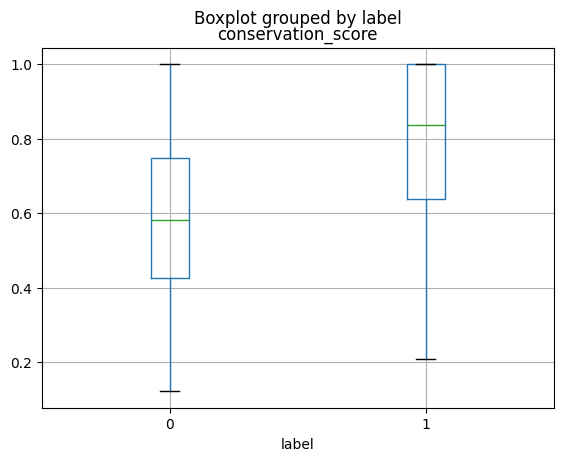

In [41]:
import matplotlib.pyplot as plt
merged_df.boxplot(column='conservation_score', by='label')
plt.show()